# Analiza wyników eksperymentów Drone Mamba

In [1]:
from pathlib import Path
import re
import json
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RUN_EVALUATION_FROM_CHECKPOINTS = True  # True tylko jeśli chcesz policzyć confusion matrix z checkpointów

# Ścieżki — uruchamiaj notebook najlepiej z głównego folderu projektu.
PROJECT_DIR = Path.cwd()
LOGS_DIR = PROJECT_DIR / "logs" / "drone_mamba"
RESULTS_DIR = PROJECT_DIR / "results"
SUMMARY_PATH = RESULTS_DIR / "summary_results_recomputed.csv"  # tworzone od nowa z checkpointów

REPORT_DIR = RESULTS_DIR / "analysis_report"
PLOTS_DIR = REPORT_DIR / "plots"
TABLES_DIR = REPORT_DIR / "tables"

for d in [REPORT_DIR, PLOTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("RECOMPUTED_SUMMARY_PATH:", SUMMARY_PATH)
print("REPORT_DIR:", REPORT_DIR)


PROJECT_DIR: c:\Users\jango\Desktop\IO\DroneAcusticDetection
LOGS_DIR: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba
RECOMPUTED_SUMMARY_PATH: c:\Users\jango\Desktop\IO\DroneAcusticDetection\results\summary_results_recomputed.csv
REPORT_DIR: c:\Users\jango\Desktop\IO\DroneAcusticDetection\results\analysis_report


In [2]:
COMMON_PARAMS = {
    "batch_size": 16,
    "max_epochs": 20,
    "learning_rate": 1e-3,
    "sample_rate": 16000,
    "duration_sec": 2.0,
    "n_mels": 128,
    "n_fft": 1024,
    "hop_length": 256,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "seed": 42,
}

DATASET_SPECIFIC_PARAMS = {
    "binary": {
        "noise_std": 0.001,
        "kalman_q": 1e-5,
        "kalman_r": 1e-6,
    },
    "multiclass": {
        "noise_std": 0.0005,
        "kalman_q": 1e-6,
        "kalman_r": 1e-5,
    },
}

def get_experiment_params(dataset_type: str) -> dict:
    """Zwraca komplet parametrów dla danego typu eksperymentu."""
    if dataset_type not in DATASET_SPECIFIC_PARAMS:
        raise ValueError("dataset_type must be 'binary' or 'multiclass'.")
    return {**COMMON_PARAMS, **DATASET_SPECIFIC_PARAMS[dataset_type]}

# Tabela do raportu — osobne parametry dla binary i multiclass.
rows = []
for dataset_type in ["binary", "multiclass"]:
    params = get_experiment_params(dataset_type)
    for k, v in params.items():
        rows.append({
            "dataset_type": dataset_type,
            "parametr": k,
            "wartość": v,
        })

params_df = pd.DataFrame(rows)
params_df.to_csv(TABLES_DIR / "experiment_parameters.csv", index=False)
params_df


,dataset_type,parametr,wartość
0,binary,batch_size,16.000000
1,binary,max_epochs,20.000000
2,binary,learning_rate,0.001000
3,binary,sample_rate,16000.000000
4,binary,duration_sec,2.000000
5,binary,n_mels,128.000000
6,binary,n_fft,1024.000000
7,binary,hop_length,256.000000
8,binary,train_ratio,0.700000
9,binary,val_ratio,0.150000


In [15]:
# KOMÓRKA 3 — funkcje pomocnicze

def parse_experiment_name(path: Path):
    """Z nazwy folderu np. binary_original robi dataset_type=binary, variant=original."""
    folder = path.parent.name
    if folder.startswith("binary_"):
        return "binary", folder.replace("binary_", "", 1)
    if folder.startswith("multiclass_"):
        return "multiclass", folder.replace("multiclass_", "", 1)
    return "unknown", folder


def compact_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Lightning CSVLogger zapisuje train i val w osobnych wierszach; sklejamy je po epoce."""
    df = df.copy()
    if "epoch" not in df.columns:
        raise ValueError("Brak kolumny 'epoch' w metrics.csv")
    out = df.groupby("epoch", as_index=False).agg(
        lambda s: s.dropna().iloc[-1] if s.dropna().shape[0] else np.nan
    )
    return out.sort_values("epoch").reset_index(drop=True)


def safe_pct(x):
    return np.nan if pd.isna(x) else 100 * float(x)


def find_best_epoch(df: pd.DataFrame, metric="val_acc"):
    if metric not in df.columns or df[metric].dropna().empty:
        return None, np.nan
    idx = df[metric].astype(float).idxmax()
    return int(df.loc[idx, "epoch"]), float(df.loc[idx, metric])


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def extract_val_acc_from_checkpoint_name(ckpt_path: Path):
    """Wyciąga val_acc z nazwy checkpointa, np. epoch=09-val_acc=0.9897.ckpt."""
    match = re.search(r"val_acc=([0-9]+(?:\.[0-9]+)?)", ckpt_path.name)
    if match is None:
        return None
    return float(match.group(1))


def choose_best_checkpoint(exp_name: str):
    """
    Wybiera najlepszy checkpoint na podstawie val_acc w nazwie pliku.
    Jeśli nie da się odczytać val_acc, wybiera najnowszy plik.
    """
    ckpt_dir = LOGS_DIR / exp_name / "checkpoints"
    ckpts = list(ckpt_dir.glob("*.ckpt"))

    if not ckpts:
        return None

    scored = []
    for ckpt in ckpts:
        score = extract_val_acc_from_checkpoint_name(ckpt)
        if score is not None:
            scored.append((ckpt, score))

    if scored:
        return max(scored, key=lambda x: x[1])[0]

    return max(ckpts, key=lambda p: p.stat().st_mtime)


def import_project_classes():
    """
    Import odporny na dwie struktury projektu:
    - src.torch_lightning.lightning_module
    - src.lightning_module
    """
    try:
        from src.torch_lightning.lightning_module import DroneClassifier
        from src.torch_lightning.lightning_data_module import DroneDataModule
    except ImportError:
        from src.lightning_module import DroneClassifier
        from src.lightning_data_module import DroneDataModule
    return DroneClassifier, DroneDataModule


DEVICE: cuda
Eksperyment: binary_original
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_original\checkpoints\binary_original-epoch=18-val_acc=0.9897.ckpt
Parametry danych: dataset_type=binary, variant=original, noise_std=0.001, kalman_q=1e-05, kalman_r=1e-06
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['unknown', 'yes_drone']
Wyniki testowe:
{'experiment': 'binary_original', 'dataset_type': 'binary', 'variant': 'original', 'num_classes': 2, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\binary_original\\checkpoints\\binary_original-epoch=18-val_acc=0.9897.ckpt', 'checkpoint_val_acc': 0.9897, 'noise_std': 0.001, 'kalman_q': 1e-05, 'kalman_r': 1e-06, 'test_loss': 0.03598878952809999, 'test_accuracy': 0.9880478087649402, 'te

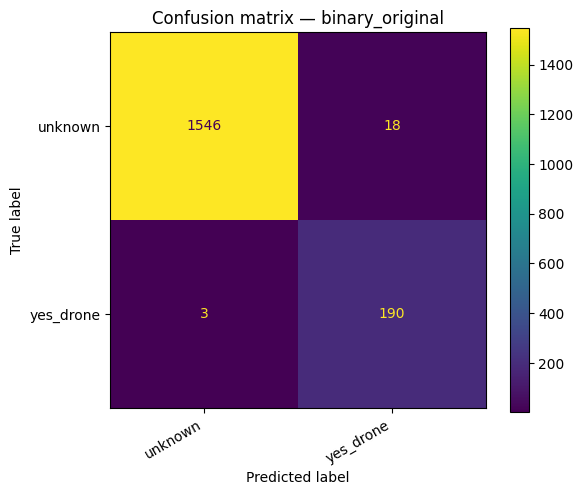

Eksperyment: binary_noisy
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_noisy\checkpoints\binary_noisy-epoch=15-val_acc=0.9954.ckpt
Parametry danych: dataset_type=binary, variant=noisy, noise_std=0.001, kalman_q=1e-05, kalman_r=1e-06
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['unknown', 'yes_drone']
Wyniki testowe:
{'experiment': 'binary_noisy', 'dataset_type': 'binary', 'variant': 'noisy', 'num_classes': 2, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\binary_noisy\\checkpoints\\binary_noisy-epoch=15-val_acc=0.9954.ckpt', 'checkpoint_val_acc': 0.9954, 'noise_std': 0.001, 'kalman_q': 1e-05, 'kalman_r': 1e-06, 'test_loss': 0.0272303363477931, 'test_accuracy': 0.9948776323278316, 'test_precision_macro': 0.9837329550654342, 

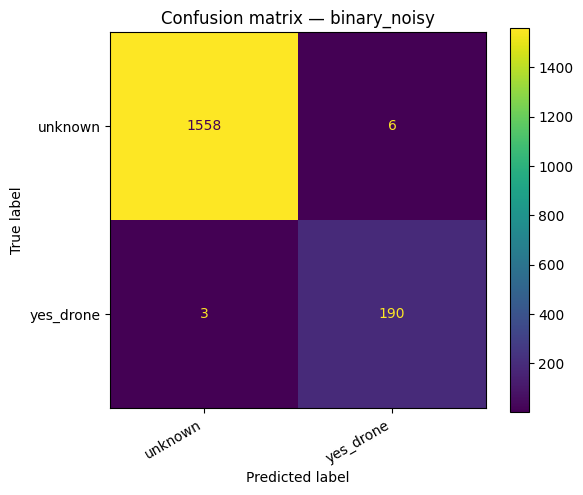

Eksperyment: binary_noisy_kalman
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_noisy_kalman\checkpoints\binary_noisy_kalman-epoch=05-val_acc=0.9846.ckpt
Parametry danych: dataset_type=binary, variant=noisy_kalman, noise_std=0.001, kalman_q=1e-05, kalman_r=1e-06
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['unknown', 'yes_drone']
Wyniki testowe:
{'experiment': 'binary_noisy_kalman', 'dataset_type': 'binary', 'variant': 'noisy_kalman', 'num_classes': 2, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\binary_noisy_kalman\\checkpoints\\binary_noisy_kalman-epoch=05-val_acc=0.9846.ckpt', 'checkpoint_val_acc': 0.9846, 'noise_std': 0.001, 'kalman_q': 1e-05, 'kalman_r': 1e-06, 'test_loss': 0.08024984835204443, 'test_accuracy': 

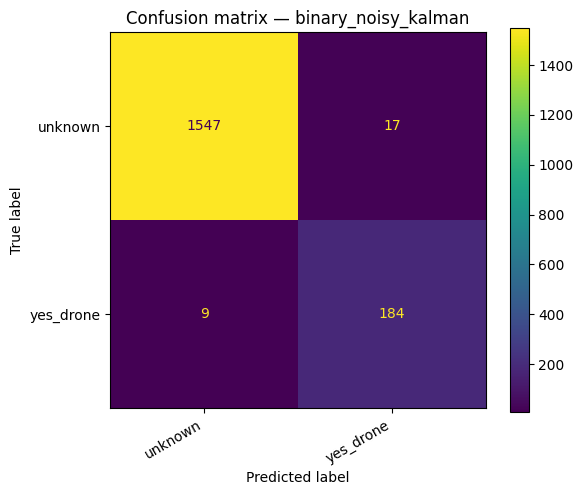

Eksperyment: multiclass_original
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_original\checkpoints\multiclass_original-epoch=12-val_acc=0.9293.ckpt
Parametry danych: dataset_type=multiclass, variant=original, noise_std=0.0005, kalman_q=1e-06, kalman_r=1e-05
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['bebop_1', 'membo_1', 'unknown']
Wyniki testowe:
{'experiment': 'multiclass_original', 'dataset_type': 'multiclass', 'variant': 'original', 'num_classes': 3, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\multiclass_original\\checkpoints\\multiclass_original-epoch=12-val_acc=0.9293.ckpt', 'checkpoint_val_acc': 0.9293, 'noise_std': 0.0005, 'kalman_q': 1e-06, 'kalman_r': 1e-05, 'test_loss': 0.337115267

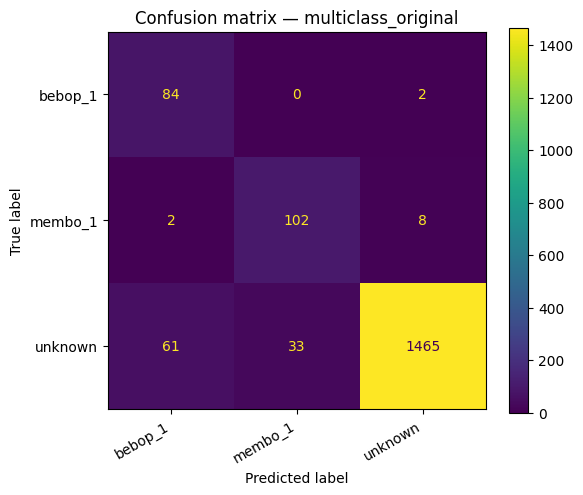

Eksperyment: multiclass_noisy
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_noisy\checkpoints\multiclass_noisy-epoch=09-val_acc=0.9897.ckpt
Parametry danych: dataset_type=multiclass, variant=noisy, noise_std=0.0005, kalman_q=1e-06, kalman_r=1e-05
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['bebop_1', 'membo_1', 'unknown']
Wyniki testowe:
{'experiment': 'multiclass_noisy', 'dataset_type': 'multiclass', 'variant': 'noisy', 'num_classes': 3, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\multiclass_noisy\\checkpoints\\multiclass_noisy-epoch=09-val_acc=0.9897.ckpt', 'checkpoint_val_acc': 0.9897, 'noise_std': 0.0005, 'kalman_q': 1e-06, 'kalman_r': 1e-05, 'test_loss': 0.08822383133267298, 'test_accuracy': 

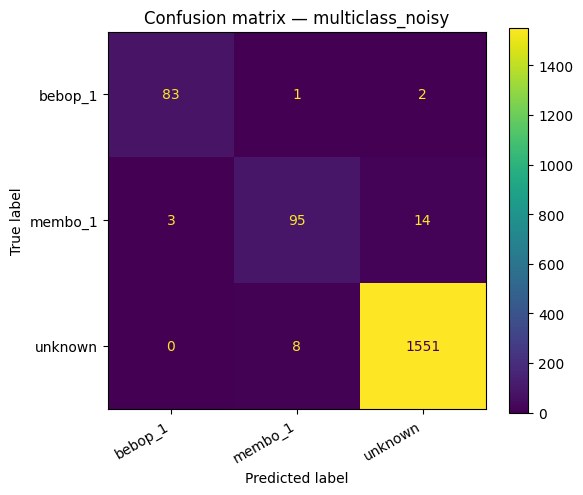

Eksperyment: multiclass_noisy_kalman
Wybrany checkpoint: c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_noisy_kalman\checkpoints\multiclass_noisy_kalman-epoch=12-val_acc=0.9886.ckpt
Parametry danych: dataset_type=multiclass, variant=noisy_kalman, noise_std=0.0005, kalman_q=1e-06, kalman_r=1e-05
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Klasy: ['bebop_1', 'membo_1', 'unknown']
Wyniki testowe:
{'experiment': 'multiclass_noisy_kalman', 'dataset_type': 'multiclass', 'variant': 'noisy_kalman', 'num_classes': 3, 'checkpoint': 'c:\\Users\\jango\\Desktop\\IO\\DroneAcusticDetection\\logs\\drone_mamba\\multiclass_noisy_kalman\\checkpoints\\multiclass_noisy_kalman-epoch=12-val_acc=0.9886.ckpt', 'checkpoint_val_acc': 0.9886, 'noise_std': 0.0005, 'kalman_q': 1e-06, 'kalman

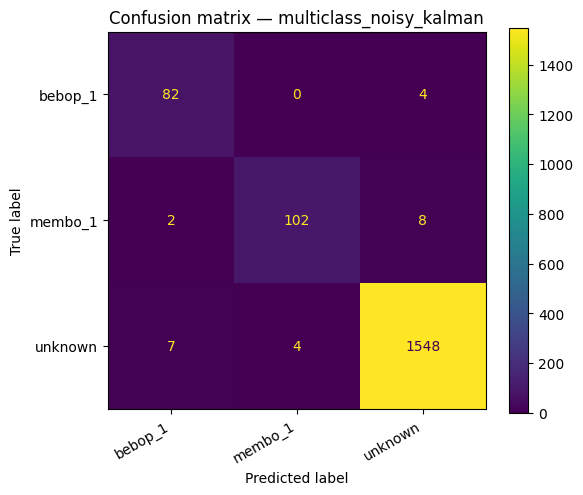

Zapisano:
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\results\summary_results_recomputed.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\results\analysis_report\tables\class_metrics_per_experiment.csv


,experiment,dataset_type,variant,num_classes,checkpoint,checkpoint_val_acc,noise_std,kalman_q,kalman_r,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,binary_original,binary,original,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9897,0.0010,0.000010,0.000001,0.035989,0.988048,0.955762,0.986474,0.970443,0.988770,0.988048,0.988243
1,binary_noisy,binary,noisy,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9954,0.0010,0.000010,0.000001,0.027230,0.994878,0.983733,0.990310,0.986992,0.994927,0.994878,0.994895
2,binary_noisy_kalman,binary,noisy_kalman,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9846,0.0010,0.000010,0.000001,0.080250,0.985202,0.954819,0.971249,0.962838,0.985561,0.985202,0.985333
3,multiclass_original,multiclass,original,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9293,0.0005,0.000001,0.000010,0.337115,0.939670,0.773401,0.942388,0.837554,0.957425,0.939670,0.944833
4,multiclass_noisy,multiclass,noisy,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9897,0.0005,0.000001,0.000010,0.088224,0.984064,0.956122,0.936066,0.945689,0.983716,0.984064,0.983807
5,multiclass_noisy_kalman,multiclass,noisy_kalman,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9886,0.0005,0.000001,0.000010,0.055230,0.985771,0.951890,0.952382,0.951653,0.985928,0.985771,0.985768


,experiment,dataset_type,variant,class,precision,recall,f1_score,support
0,binary_original,binary,original,unknown,0.998063,0.988491,0.993254,1564.0
1,binary_original,binary,original,yes_drone,0.913462,0.984456,0.947631,193.0
2,binary_noisy,binary,noisy,unknown,0.998078,0.996164,0.997120,1564.0
3,binary_noisy,binary,noisy,yes_drone,0.969388,0.984456,0.976864,193.0
4,binary_noisy_kalman,binary,noisy_kalman,unknown,0.994216,0.989130,0.991667,1564.0
5,binary_noisy_kalman,binary,noisy_kalman,yes_drone,0.915423,0.953368,0.934010,193.0
6,multiclass_original,multiclass,original,bebop_1,0.571429,0.976744,0.721030,86.0
7,multiclass_original,multiclass,original,membo_1,0.755556,0.910714,0.825911,112.0
8,multiclass_original,multiclass,original,unknown,0.993220,0.939705,0.965722,1559.0
9,multiclass_noisy,multiclass,noisy,bebop_1,0.965116,0.965116,0.965116,86.0


In [16]:
# KOMÓRKA 4 — odbudowanie wyników testowych z checkpointów
# NIE CZYTA summary_results.csv.
# NIE TRENUJE MODELU.
# Liczy od zera na zbiorze testowym: accuracy, precision, recall, F1, loss oraz confusion matrix.

if RUN_EVALUATION_FROM_CHECKPOINTS:
    import torch
    import torch.nn as nn
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        classification_report,
        ConfusionMatrixDisplay,
    )

    DroneClassifier, DroneDataModule = import_project_classes()

    CM_DIR = REPORT_DIR / "confusion_matrices"
    CM_DIR.mkdir(parents=True, exist_ok=True)

    EXPERIMENT_CONFIGS = {
        "binary_original": {
            "dataset_type": "binary",
            "variant": "original",
            "num_classes": 2,
        },
        "binary_noisy": {
            "dataset_type": "binary",
            "variant": "noisy",
            "num_classes": 2,
        },
        "binary_noisy_kalman": {
            "dataset_type": "binary",
            "variant": "noisy_kalman",
            "num_classes": 2,
        },
        "multiclass_original": {
            "dataset_type": "multiclass",
            "variant": "original",
            "num_classes": 3,
        },
        "multiclass_noisy": {
            "dataset_type": "multiclass",
            "variant": "noisy",
            "num_classes": 3,
        },
        "multiclass_noisy_kalman": {
            "dataset_type": "multiclass",
            "variant": "noisy_kalman",
            "num_classes": 3,
        },
    }

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("DEVICE:", DEVICE)

    recomputed_rows = []
    class_rows = []

    for exp_name, cfg in EXPERIMENT_CONFIGS.items():
        dataset_type = cfg["dataset_type"]
        variant = cfg["variant"]
        num_classes = cfg["num_classes"]
        params = get_experiment_params(dataset_type)

        ckpt_path = choose_best_checkpoint(exp_name)

        print("=" * 90)
        print("Eksperyment:", exp_name)

        if ckpt_path is None:
            print(f"[POMINIĘTO] Brak checkpointa dla {exp_name}")
            continue

        print("Wybrany checkpoint:", ckpt_path)
        print(
            f"Parametry danych: dataset_type={dataset_type}, variant={variant}, "
            f"noise_std={params['noise_std']}, kalman_q={params['kalman_q']}, kalman_r={params['kalman_r']}"
        )

        dm = DroneDataModule(
            root_dir="data",
            dataset_type=dataset_type,
            variant=variant,
            batch_size=params["batch_size"],
            num_workers=0,
            sample_rate=params["sample_rate"],
            duration=params["duration_sec"],
            n_mels=params["n_mels"],
            n_fft=params["n_fft"],
            hop_length=params["hop_length"],
            noise_std=params["noise_std"],
            kalman_q=params["kalman_q"],
            kalman_r=params["kalman_r"],
            train_ratio=params["train_ratio"],
            val_ratio=params["val_ratio"],
            test_ratio=params["test_ratio"],
            seed=params["seed"],
        )
        dm.setup("test")

        class_names = [dm.idx_to_class[i] for i in range(num_classes)]
        print("Klasy:", class_names)

        model = DroneClassifier.load_from_checkpoint(
            str(ckpt_path),
            num_classes=num_classes,
            n_mels=params["n_mels"],
            learning_rate=params["learning_rate"],
        )
        model.eval()
        model.to(DEVICE)

        loss_fn = nn.CrossEntropyLoss()

        y_true = []
        y_pred = []
        total_loss = 0.0
        total_count = 0

        with torch.no_grad():
            for x, y in dm.test_dataloader():
                x = x.to(DEVICE)
                y_device = y.to(DEVICE)

                logits = model(x)
                loss = loss_fn(logits, y_device)

                preds = torch.argmax(logits, dim=1).cpu().numpy()

                batch_size = y.shape[0]
                total_loss += float(loss.item()) * batch_size
                total_count += batch_size

                y_pred.extend(preds.tolist())
                y_true.extend(y.numpy().tolist())

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        test_loss = total_loss / max(total_count, 1)
        test_accuracy = accuracy_score(y_true, y_pred)

        test_precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
        test_recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
        test_f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        test_precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        test_recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        test_f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

        row = {
            "experiment": exp_name,
            "dataset_type": dataset_type,
            "variant": variant,
            "num_classes": num_classes,
            "checkpoint": str(ckpt_path),
            "checkpoint_val_acc": extract_val_acc_from_checkpoint_name(ckpt_path),
            "noise_std": params["noise_std"],
            "kalman_q": params["kalman_q"],
            "kalman_r": params["kalman_r"],
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
            "test_precision_macro": test_precision_macro,
            "test_recall_macro": test_recall_macro,
            "test_f1_macro": test_f1_macro,
            "test_precision_weighted": test_precision_weighted,
            "test_recall_weighted": test_recall_weighted,
            "test_f1_weighted": test_f1_weighted,
        }
        recomputed_rows.append(row)

        print("Wyniki testowe:")
        print(row)

        report_dict = classification_report(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            target_names=class_names,
            zero_division=0,
            output_dict=True,
        )
        report_df = pd.DataFrame(report_dict).T
        report_df.to_csv(TABLES_DIR / f"classification_report_{exp_name}.csv")

        for class_name in class_names:
            if class_name in report_dict:
                class_rows.append({
                    "experiment": exp_name,
                    "dataset_type": dataset_type,
                    "variant": variant,
                    "class": class_name,
                    "precision": report_dict[class_name]["precision"],
                    "recall": report_dict[class_name]["recall"],
                    "f1_score": report_dict[class_name]["f1-score"],
                    "support": report_dict[class_name]["support"],
                })

        cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
        cm_df.to_csv(TABLES_DIR / f"confusion_matrix_{exp_name}.csv")

        fig, ax = plt.subplots(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, values_format="d", colorbar=True)
        ax.set_title(f"Confusion matrix — {exp_name}")
        plt.xticks(rotation=30, ha="right")
        savefig(CM_DIR / f"confusion_matrix_{exp_name}.png")

    summary_df = pd.DataFrame(recomputed_rows)
    class_metrics_df = pd.DataFrame(class_rows)

    summary_df.to_csv(RESULTS_DIR / "summary_results_recomputed.csv", index=False)
    summary_df.to_csv(TABLES_DIR / "summary_results_recomputed.csv", index=False)
    class_metrics_df.to_csv(TABLES_DIR / "class_metrics_per_experiment.csv", index=False)

    print("Zapisano:")
    print(" -", RESULTS_DIR / "summary_results_recomputed.csv")
    print(" -", TABLES_DIR / "class_metrics_per_experiment.csv")

    display(summary_df)
    display(class_metrics_df)

else:
    print("RUN_EVALUATION_FROM_CHECKPOINTS=False — pomijam ewaluację checkpointów.")
    print("Ustaw True w komórce 1, jeśli chcesz policzyć test accuracy/precision/recall/F1/confusion matrix.")
    summary_df = pd.DataFrame()
    class_metrics_df = pd.DataFrame()


In [5]:
# KOMÓRKA 5 — wczytanie wszystkich plików metrics.csv
# Szuka rekurencyjnie w logs/drone_mamba/**/metrics.csv.
# Awaryjnie bierze metrics.csv z bieżącego folderu.

metrics_paths = sorted(LOGS_DIR.glob("**/metrics.csv"))
if not metrics_paths:
    fallback = PROJECT_DIR / "metrics.csv"
    if fallback.exists():
        metrics_paths = [fallback]

print("Znalezione pliki metrics.csv:")
for p in metrics_paths:
    print(" -", p)

metrics_raw = {}
metrics_epoch = {}

for p in metrics_paths:
    dataset_type, variant = parse_experiment_name(p)
    key = f"{dataset_type}_{variant}"
    df = pd.read_csv(p)
    metrics_raw[key] = df
    metrics_epoch[key] = compact_metrics(df)

print("\nEksperymenty:", list(metrics_epoch.keys()))

# Podgląd pierwszego eksperymentu
if metrics_epoch:
    first_key = list(metrics_epoch.keys())[0]
    print("Podgląd:", first_key)
    display(metrics_epoch[first_key].head())


Znalezione pliki metrics.csv:
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_noisy\metrics.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_noisy_kalman\metrics.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\binary_original\metrics.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_noisy\metrics.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_noisy_kalman\metrics.csv
 - c:\Users\jango\Desktop\IO\DroneAcusticDetection\logs\drone_mamba\multiclass_original\metrics.csv

Eksperymenty: ['binary_noisy', 'binary_noisy_kalman', 'binary_original', 'multiclass_noisy', 'multiclass_noisy_kalman', 'multiclass_original']
Podgląd: binary_noisy


,epoch,step,test_acc,test_f1,test_loss,train_acc,train_loss,val_acc,val_loss
0,0,511,NaN,NaN,NaN,0.765991,0.965998,0.874644,0.380703
1,1,1023,NaN,NaN,NaN,0.881226,0.322979,0.969231,0.374042
2,2,1535,NaN,NaN,NaN,0.891235,0.337183,0.960684,0.232642
3,3,2047,NaN,NaN,NaN,0.929199,0.238342,0.830769,0.477678
4,4,2559,NaN,NaN,NaN,0.942017,0.185532,0.951567,0.170136


In [6]:
# KOMÓRKA 6 — tabela: najlepsze epoki i ostatnie wartości z metrics.csv
rows = []
for key, df in metrics_epoch.items():
    dataset_type, variant = key.split("_", 1) if "_" in key else ("unknown", key)
    best_epoch, best_val_acc = find_best_epoch(df, "val_acc")
    best_loss_epoch = None
    best_val_loss = np.nan
    if "val_loss" in df.columns and not df["val_loss"].dropna().empty:
        idx = df["val_loss"].astype(float).idxmin()
        best_loss_epoch = int(df.loc[idx, "epoch"])
        best_val_loss = float(df.loc[idx, "val_loss"])

    rows.append({
        "experiment": key,
        "dataset_type": dataset_type,
        "variant": variant,
        "best_epoch_by_val_acc": best_epoch,
        "best_val_acc": best_val_acc,
        "best_epoch_by_val_loss": best_loss_epoch,
        "best_val_loss": best_val_loss,
        "last_train_loss": df["train_loss"].dropna().iloc[-1] if "train_loss" in df and not df["train_loss"].dropna().empty else np.nan,
        "last_val_loss": df["val_loss"].dropna().iloc[-1] if "val_loss" in df and not df["val_loss"].dropna().empty else np.nan,
        "last_train_acc": df["train_acc"].dropna().iloc[-1] if "train_acc" in df and not df["train_acc"].dropna().empty else np.nan,
        "last_val_acc": df["val_acc"].dropna().iloc[-1] if "val_acc" in df and not df["val_acc"].dropna().empty else np.nan,
        "test_acc_from_metrics": df["test_acc"].dropna().iloc[-1] if "test_acc" in df and not df["test_acc"].dropna().empty else np.nan,
        "test_f1_from_metrics": df["test_f1"].dropna().iloc[-1] if "test_f1" in df and not df["test_f1"].dropna().empty else np.nan,
        "test_loss_from_metrics": df["test_loss"].dropna().iloc[-1] if "test_loss" in df and not df["test_loss"].dropna().empty else np.nan,
    })

metrics_summary_df = pd.DataFrame(rows)
metrics_summary_df.to_csv(TABLES_DIR / "metrics_summary.csv", index=False)
display(metrics_summary_df)


,experiment,dataset_type,variant,best_epoch_by_val_acc,best_val_acc,best_epoch_by_val_loss,best_val_loss,last_train_loss,last_val_loss,last_train_acc,last_val_acc,test_acc_from_metrics,test_f1_from_metrics,test_loss_from_metrics
0,binary_noisy,binary,noisy,15,0.995442,15,0.028156,0.060176,0.066135,0.983887,0.977208,0.977803,0.947592,0.073423
1,binary_noisy_kalman,binary,noisy_kalman,5,0.984615,9,0.056077,0.078876,0.073429,0.978516,0.970940,0.976096,0.943904,0.065498
2,binary_original,binary,original,18,0.989744,19,0.044186,0.040379,0.044186,0.982544,0.986895,0.982356,0.957292,0.229628
3,multiclass_noisy,multiclass,noisy,5,0.978917,6,0.212375,0.245808,0.239541,0.934448,0.974929,0.976665,0.920526,0.225156
4,multiclass_noisy_kalman,multiclass,noisy_kalman,12,0.988604,15,0.044772,0.052761,0.066761,0.983643,0.986325,0.984633,0.949264,0.060934
5,multiclass_original,multiclass,original,6,0.976068,6,0.089803,0.072677,0.176587,0.976440,0.954416,0.953899,0.885711,0.182562


In [7]:
# KOMÓRKA 7 — tabela końcowa
# Wyniki testowe pochodzą WYŁĄCZNIE z ewaluacji checkpointów w KOMÓRCE 4.
# metrics.csv jest używany tylko do przebiegu uczenia: train_loss, val_loss, train_acc, val_acc.

if not summary_df.empty and not metrics_summary_df.empty:
    final_summary = summary_df.merge(
        metrics_summary_df,
        on=["experiment", "dataset_type", "variant"],
        how="left"
    )
elif not summary_df.empty:
    final_summary = summary_df.copy()
elif not metrics_summary_df.empty:
    final_summary = metrics_summary_df.copy()
else:
    final_summary = pd.DataFrame()

if not final_summary.empty:
    final_summary.to_csv(TABLES_DIR / "final_summary.csv", index=False)
    display(final_summary)
else:
    print("Brak danych do tabeli końcowej.")


,experiment,dataset_type,variant,num_classes,checkpoint,checkpoint_val_acc,noise_std,kalman_q,kalman_r,test_loss,...,best_val_acc,best_epoch_by_val_loss,best_val_loss,last_train_loss,last_val_loss,last_train_acc,last_val_acc,test_acc_from_metrics,test_f1_from_metrics,test_loss_from_metrics
0,binary_original,binary,original,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9897,0.0010,0.000010,0.000001,0.035989,...,0.989744,19,0.044186,0.040379,0.044186,0.982544,0.986895,0.982356,0.957292,0.229628
1,binary_noisy,binary,noisy,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9954,0.0010,0.000010,0.000001,0.026598,...,0.995442,15,0.028156,0.060176,0.066135,0.983887,0.977208,0.977803,0.947592,0.073423
2,binary_noisy_kalman,binary,noisy_kalman,2,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9846,0.0010,0.000010,0.000001,0.079969,...,0.984615,9,0.056077,0.078876,0.073429,0.978516,0.970940,0.976096,0.943904,0.065498
3,multiclass_original,multiclass,original,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.8718,0.0005,0.000001,0.000010,0.337445,...,0.976068,6,0.089803,0.072677,0.176587,0.976440,0.954416,0.953899,0.885711,0.182562
4,multiclass_noisy,multiclass,noisy,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9897,0.0005,0.000001,0.000010,0.087862,...,0.978917,6,0.212375,0.245808,0.239541,0.934448,0.974929,0.976665,0.920526,0.225156
5,multiclass_noisy_kalman,multiclass,noisy_kalman,3,c:\Users\jango\Desktop\IO\DroneAcusticDetectio...,0.9886,0.0005,0.000001,0.000010,0.055702,...,0.988604,15,0.044772,0.052761,0.066761,0.983643,0.986325,0.984633,0.949264,0.060934


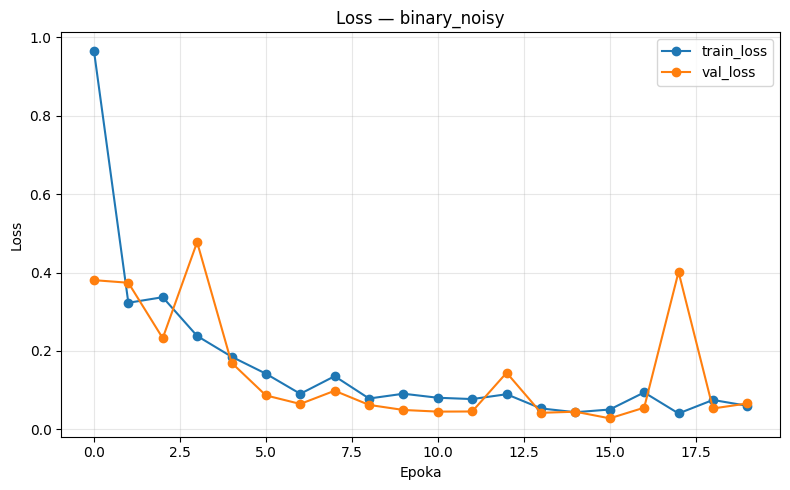

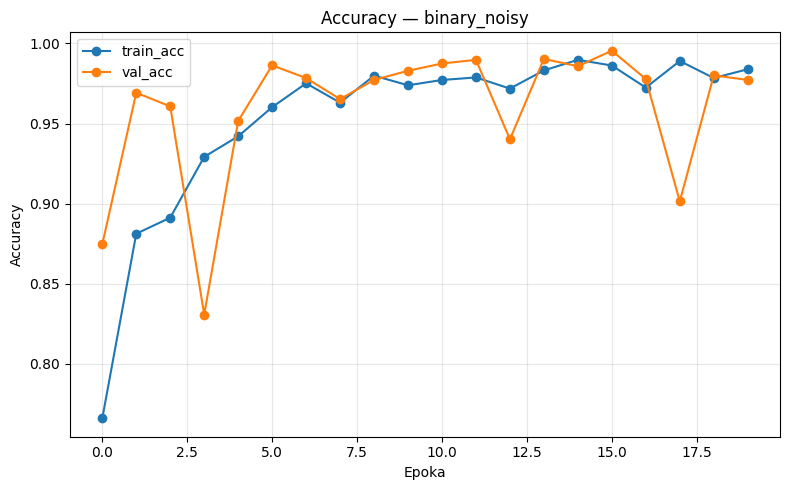

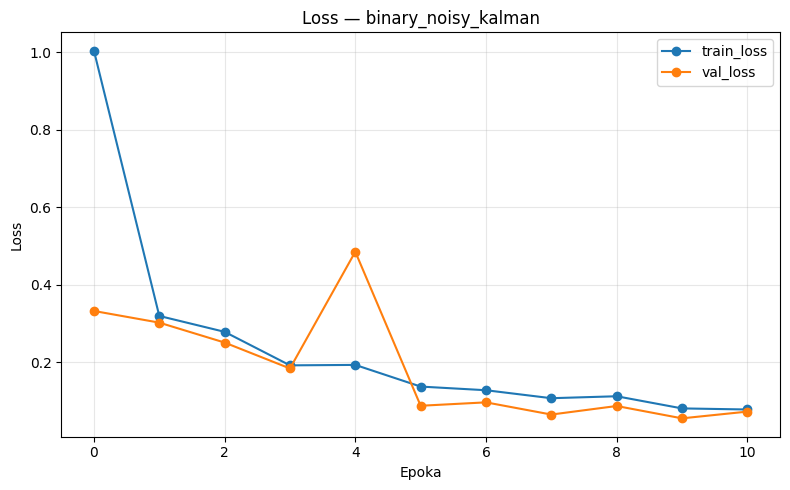

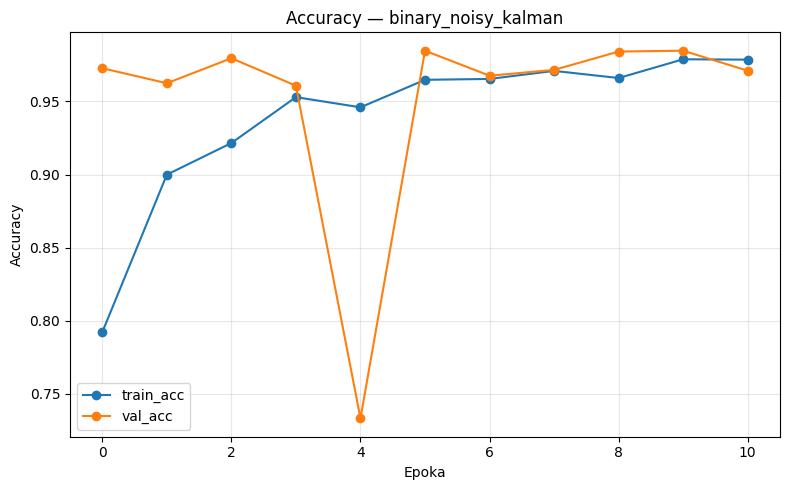

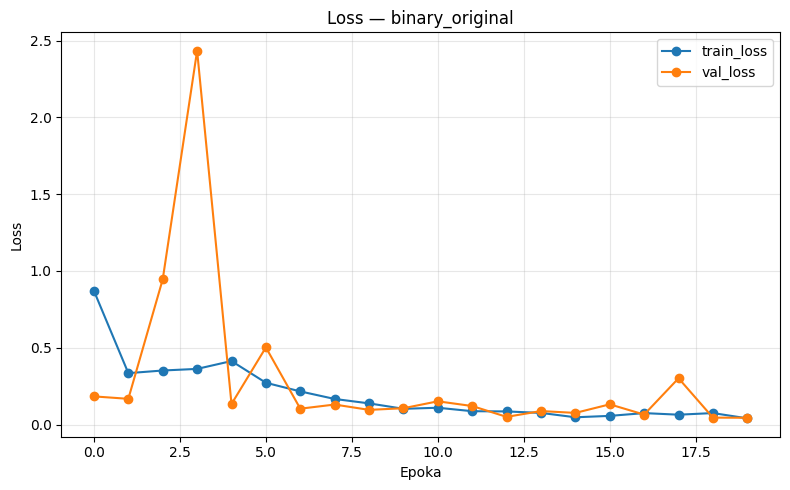

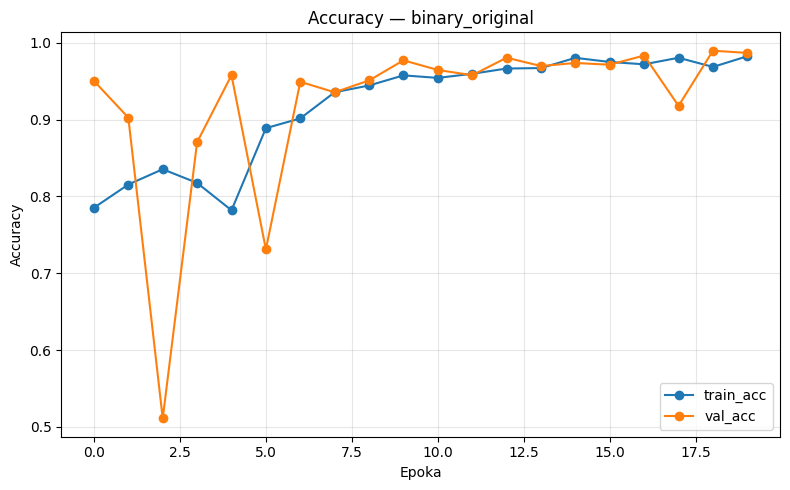

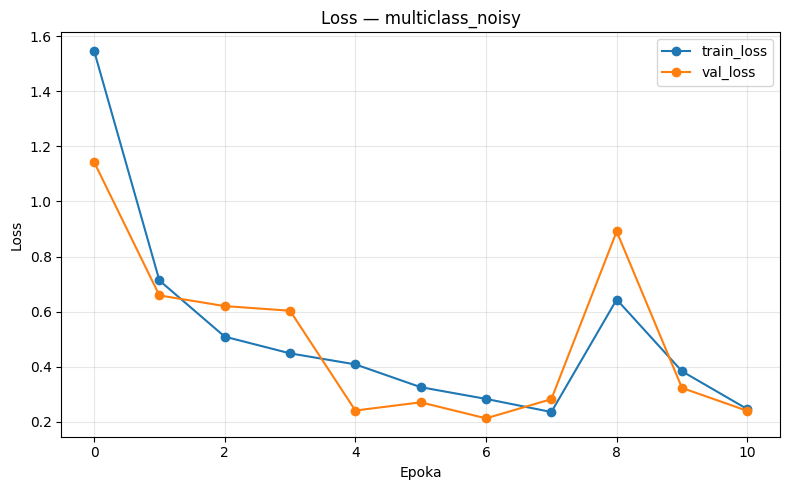

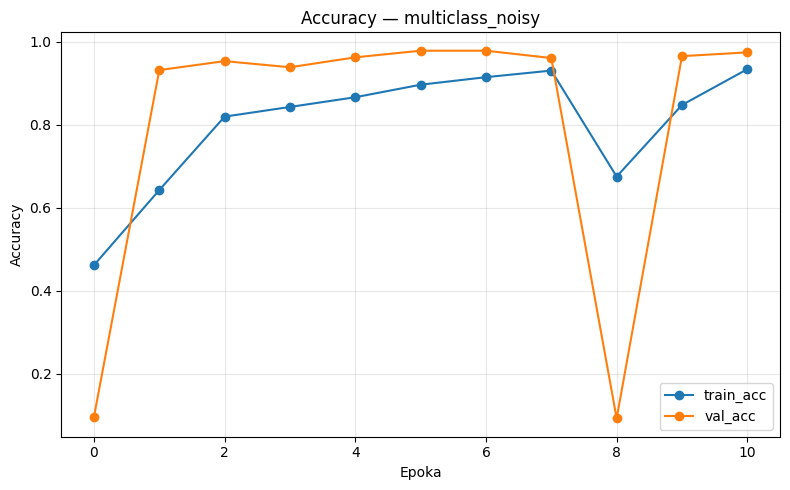

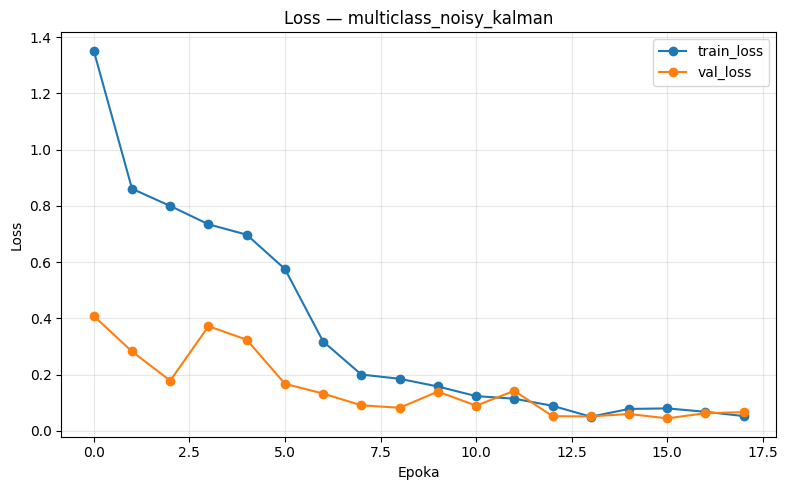

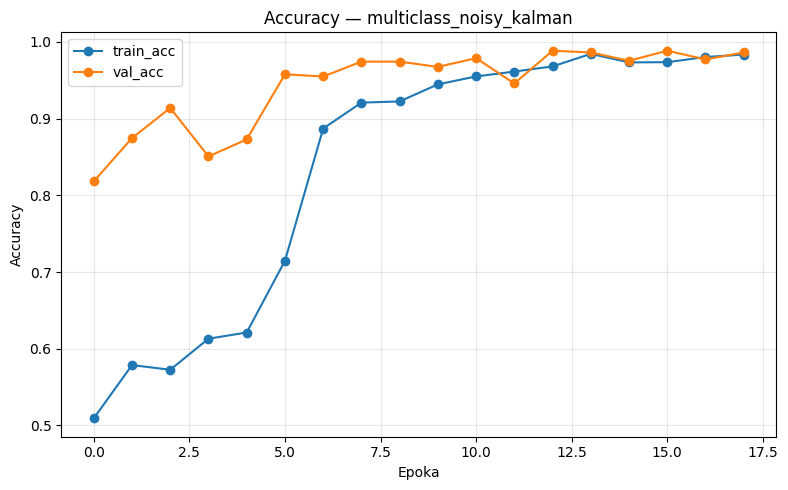

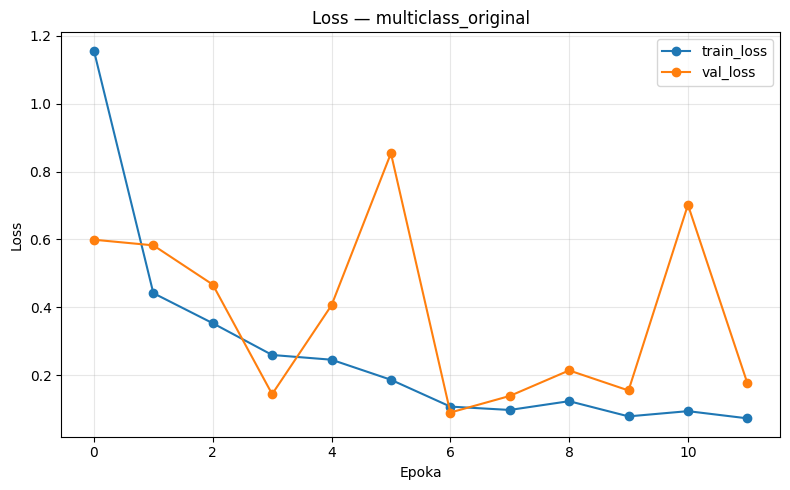

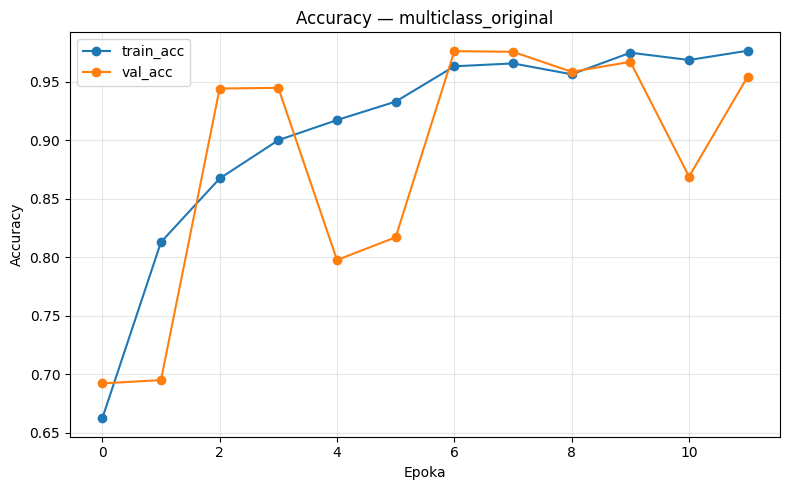

In [8]:
# KOMÓRKA 8 — wykresy loss/accuracy dla każdego eksperymentu osobno
for key, df in metrics_epoch.items():
    # Loss
    plt.figure(figsize=(8, 5))
    if "train_loss" in df.columns:
        plt.plot(df["epoch"], df["train_loss"], marker="o", label="train_loss")
    if "val_loss" in df.columns:
        plt.plot(df["epoch"], df["val_loss"], marker="o", label="val_loss")
    plt.title(f"Loss — {key}")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig(PLOTS_DIR / f"{key}_loss.png")

    # Accuracy
    plt.figure(figsize=(8, 5))
    if "train_acc" in df.columns:
        plt.plot(df["epoch"], df["train_acc"], marker="o", label="train_acc")
    if "val_acc" in df.columns:
        plt.plot(df["epoch"], df["val_acc"], marker="o", label="val_acc")
    plt.title(f"Accuracy — {key}")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig(PLOTS_DIR / f"{key}_accuracy.png")


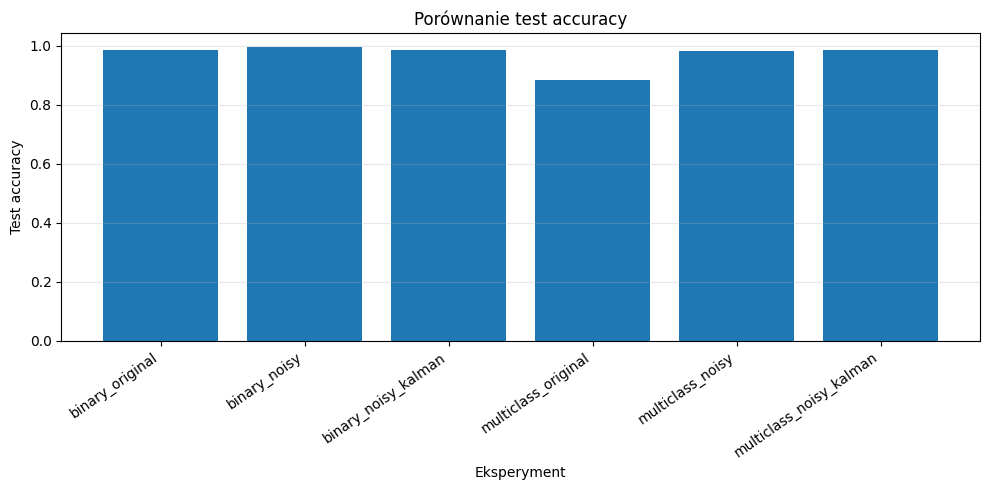

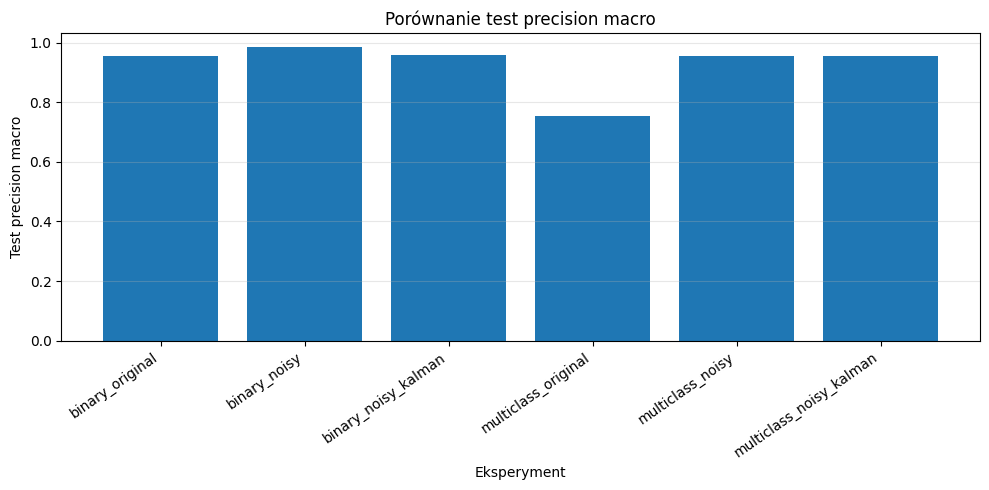

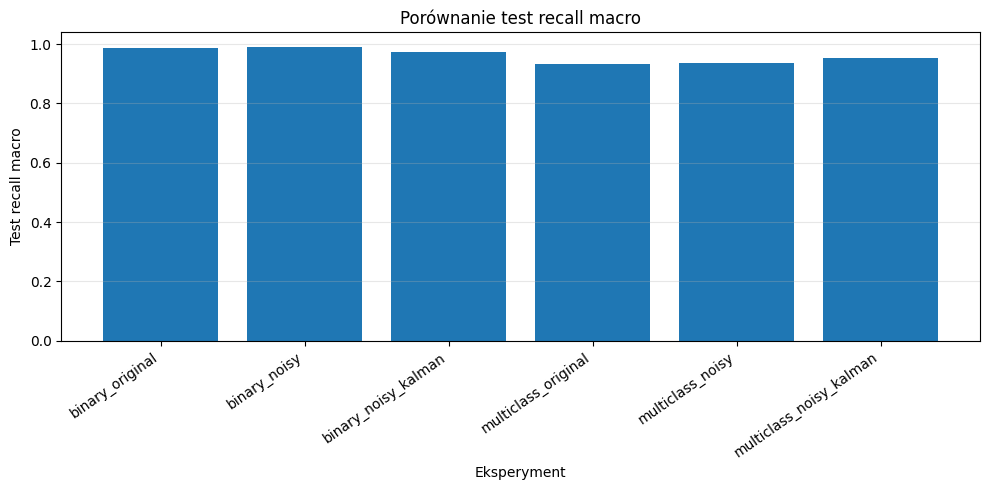

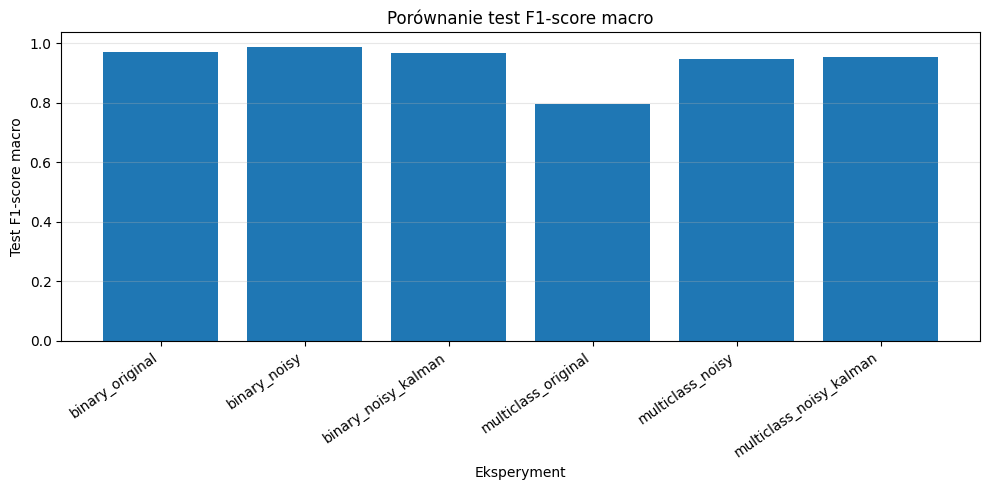

In [9]:
# KOMÓRKA 9 — wykresy porównawcze wyników testowych liczonych z checkpointów

if not summary_df.empty:
    plot_df = summary_df.copy()

    metrics_to_plot = [
        ("test_accuracy", "Porównanie test accuracy", "Test accuracy", "comparison_test_accuracy.png"),
        ("test_precision_macro", "Porównanie test precision macro", "Test precision macro", "comparison_test_precision_macro.png"),
        ("test_recall_macro", "Porównanie test recall macro", "Test recall macro", "comparison_test_recall_macro.png"),
        ("test_f1_macro", "Porównanie test F1-score macro", "Test F1-score macro", "comparison_test_f1_macro.png"),
    ]

    for col, title, ylabel, filename in metrics_to_plot:
        if col in plot_df.columns:
            plt.figure(figsize=(10, 5))
            plt.bar(plot_df["experiment"], plot_df[col])
            plt.title(title)
            plt.xlabel("Eksperyment")
            plt.ylabel(ylabel)
            plt.xticks(rotation=35, ha="right")
            plt.grid(True, axis="y", alpha=0.3)
            savefig(PLOTS_DIR / filename)
else:
    print("Brak wyników z checkpointów — pomijam wykresy porównawcze testowe.")


In [10]:
# KOMÓRKA 10 — analiza wpływu szumu i filtru Kalmana
# Liczymy różnice względem wariantu original osobno dla binary i multiclass.
# Dane pochodzą z testu checkpointów, nie z summary_results.csv.

if not summary_df.empty:
    comparisons = []
    for dataset_type in summary_df["dataset_type"].unique():
        part = summary_df[summary_df["dataset_type"] == dataset_type]
        base = part[part["variant"] == "original"]
        if base.empty:
            continue

        base = base.iloc[0]

        for _, row in part.iterrows():
            comparisons.append({
                "dataset_type": dataset_type,
                "variant": row["variant"],
                "test_accuracy": row.get("test_accuracy", np.nan),
                "test_precision_macro": row.get("test_precision_macro", np.nan),
                "test_recall_macro": row.get("test_recall_macro", np.nan),
                "test_f1_macro": row.get("test_f1_macro", np.nan),
                "delta_accuracy_vs_original": row.get("test_accuracy", np.nan) - base.get("test_accuracy", np.nan),
                "delta_precision_macro_vs_original": row.get("test_precision_macro", np.nan) - base.get("test_precision_macro", np.nan),
                "delta_recall_macro_vs_original": row.get("test_recall_macro", np.nan) - base.get("test_recall_macro", np.nan),
                "delta_f1_macro_vs_original": row.get("test_f1_macro", np.nan) - base.get("test_f1_macro", np.nan),
                "delta_accuracy_pp_vs_original": 100 * (row.get("test_accuracy", np.nan) - base.get("test_accuracy", np.nan)),
                "delta_f1_macro_pp_vs_original": 100 * (row.get("test_f1_macro", np.nan) - base.get("test_f1_macro", np.nan)),
            })

    comp_df = pd.DataFrame(comparisons)
    comp_df.to_csv(TABLES_DIR / "noise_kalman_comparison.csv", index=False)
    display(comp_df)
else:
    comp_df = pd.DataFrame()
    print("Brak wyników z checkpointów — pomijam analizę różnic względem original.")


,dataset_type,variant,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,delta_accuracy_vs_original,delta_precision_macro_vs_original,delta_recall_macro_vs_original,delta_f1_macro_vs_original,delta_accuracy_pp_vs_original,delta_f1_macro_pp_vs_original
0,binary,original,0.988048,0.955762,0.986474,0.970443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,binary,noisy,0.994878,0.983733,0.990310,0.986992,0.006830,0.027971,0.003836,0.016549,0.682982,1.654937
2,binary,noisy_kalman,0.986340,0.957628,0.974160,0.965697,-0.001707,0.001866,-0.012314,-0.004746,-0.170746,-0.474552
3,multiclass,original,0.886170,0.752625,0.934302,0.796572,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,multiclass,noisy,0.984064,0.956122,0.936066,0.945689,0.097894,0.203497,0.001765,0.149117,9.789414,14.911732
5,multiclass,noisy_kalman,0.986340,0.955229,0.952596,0.953516,0.100171,0.202604,0.018294,0.156943,10.017075,15.694344


In [11]:
# KOMÓRKA 11 — automatyczne wnioski tekstowe do raportu
# Wyniki testowe są liczone z checkpointów, a nie przepisywane z summary_results.csv.

lines = []
lines.append("# Wnioski automatycznie wygenerowane na podstawie wyników\n")

lines.append("## Parametry eksperymentu")
lines.append(
    f"We wszystkich eksperymentach wykorzystano spektrogramy melowe o liczbie pasm "
    f"n_mels={COMMON_PARAMS['n_mels']}, długości próbek {COMMON_PARAMS['duration_sec']} s "
    f"oraz częstotliwości próbkowania {COMMON_PARAMS['sample_rate']} Hz."
)

for dataset_type in ["binary", "multiclass"]:
    p = get_experiment_params(dataset_type)
    lines.append(
        f"Dla eksperymentów typu {dataset_type} zastosowano: "
        f"noise_std={p['noise_std']}, kalman_q={p['kalman_q']}, kalman_r={p['kalman_r']}."
    )
lines.append("")

if not summary_df.empty:
    lines.append("## Wyniki testowe z checkpointów")
    for _, row in summary_df.iterrows():
        lines.append(
            f"- {row['dataset_type']} / {row['variant']}: "
            f"accuracy={100*row.get('test_accuracy', np.nan):.2f}%, "
            f"precision_macro={row.get('test_precision_macro', np.nan):.4f}, "
            f"recall_macro={row.get('test_recall_macro', np.nan):.4f}, "
            f"F1_macro={row.get('test_f1_macro', np.nan):.4f}, "
            f"loss={row.get('test_loss', np.nan):.4f}."
        )
    lines.append("")

if not metrics_summary_df.empty:
    lines.append("## Przebieg uczenia")
    for _, row in metrics_summary_df.iterrows():
        lines.append(
            f"- {row['experiment']}: najlepsza wartość val_acc={row.get('best_val_acc', np.nan):.4f} "
            f"w epoce {row.get('best_epoch_by_val_acc', np.nan)}; "
            f"najniższy val_loss={row.get('best_val_loss', np.nan):.4f}."
        )
    lines.append("")

if 'comp_df' in globals() and not comp_df.empty:
    lines.append("## Wpływ szumu i filtru Kalmana")
    for _, row in comp_df.iterrows():
        if row["variant"] == "original":
            continue

        p = get_experiment_params(row["dataset_type"])
        lines.append(
            f"- {row['dataset_type']} / {row['variant']}: względem wariantu original "
            f"zmiana accuracy wyniosła {row['delta_accuracy_pp_vs_original']:.2f} p.p., "
            f"a zmiana F1_macro wyniosła {row['delta_f1_macro_vs_original']:.4f}. "
            f"Parametry dla tego typu danych: noise_std={p['noise_std']}, "
            f"kalman_q={p['kalman_q']}, kalman_r={p['kalman_r']}."
        )
    lines.append("")

report_text = "\n".join(lines)
with open(REPORT_DIR / "automatic_conclusions.md", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("Zapisano:", REPORT_DIR / "automatic_conclusions.md")


# Wnioski automatycznie wygenerowane na podstawie wyników

## Parametry eksperymentu
We wszystkich eksperymentach wykorzystano spektrogramy melowe o liczbie pasm n_mels=128, długości próbek 2.0 s oraz częstotliwości próbkowania 16000 Hz.
Dla eksperymentów typu binary zastosowano: noise_std=0.001, kalman_q=1e-05, kalman_r=1e-06.
Dla eksperymentów typu multiclass zastosowano: noise_std=0.0005, kalman_q=1e-06, kalman_r=1e-05.

## Wyniki testowe z checkpointów
- binary / original: accuracy=98.80%, precision_macro=0.9558, recall_macro=0.9865, F1_macro=0.9704, loss=0.0360.
- binary / noisy: accuracy=99.49%, precision_macro=0.9837, recall_macro=0.9903, F1_macro=0.9870, loss=0.0266.
- binary / noisy_kalman: accuracy=98.63%, precision_macro=0.9576, recall_macro=0.9742, F1_macro=0.9657, loss=0.0800.
- multiclass / original: accuracy=88.62%, precision_macro=0.7526, recall_macro=0.9343, F1_macro=0.7966, loss=0.3374.
- multiclass / noisy: accuracy=98.41%, precision_macro=0.9561, recall_macro=0.9361